In [1]:
import numpy as np
import yaml
import os
import sys
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns



(100,)


ValueError: x and y must have same first dimension, but have shapes (200,) and (100,)

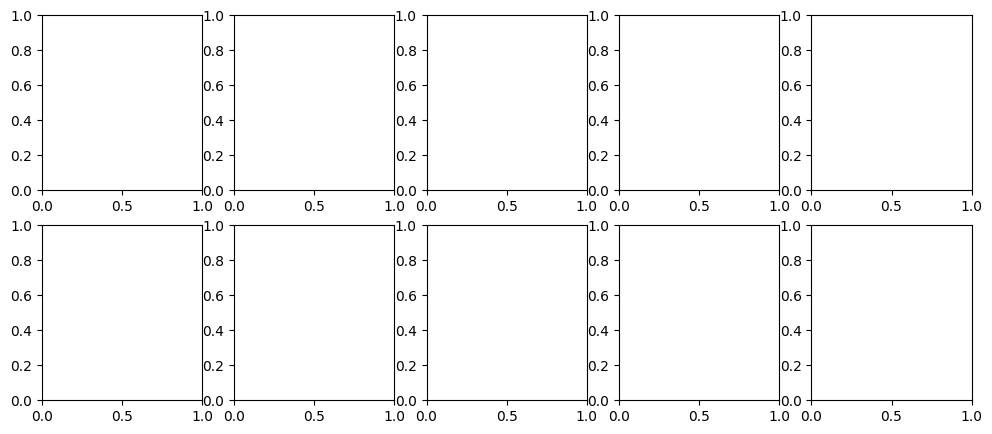

In [2]:
data=np.load("results/ratd/double_well.npz")
full_trajectories,time=data["full_trajectories"],data["time"]

z=5

samples=data["samples"]
train_test_split=data["train_test_split"]
prediction_length=data["prediction_length"]
time_test=time[train_test_split:]
ci90_lower        = data["ci90_lower"]
ci90_upper        = data["ci90_upper"]    
#fig,ax=plt.subplots(2,2,figsize=(12,5))
#ax=ax.flatten()
contexts=data["contexts"]
gt=data["ground_truth"]

#print(contexts.shape)

fig,axe=plt.subplots(2,5,figsize=(12,5))
print(samples[z,0,:].shape)
#print(samples[z][1])
axe=axe.flatten()
for i in range(10):
    ft=full_trajectories[i]
    ctx=contexts[i]
    axe[i].plot(time[train_test_split-prediction_length:],samples[i,0,:],color="red",alpha=0.4)
    axe[i].plot(time[train_test_split-prediction_length:train_test_split],ctx,color="blue")
    axe[i].plot(time[train_test_split-prediction_length:],gt[i],color="black",linestyle="--")
    axe[i].axvline(time[train_test_split],linestyle="--",color="blue",alpha=0.3)
    axe[i].set_ylim(-1.5,1.5)

False


(-1.5, 1.5)

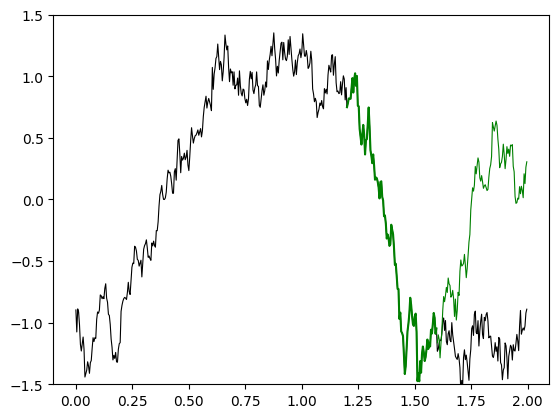

In [ ]:

s=samples[z][1]
median=np.median(samples, axis=0)
plt.plot(time,ft,color="black", linewidth=0.8, label="ground truth")
plt.plot(time[train_test_split-prediction_length:train_test_split],ctx, color="green")
#plt.plot(time_test,ft[train_test_split:train_test_split + prediction_length],color="black", linewidth=0.8, linestyle="--", label="Ground Truth")
#if sample is not None:
        # samples_to_plot shape: [num_futures, time]
        # Transpose to [time, num_futures] so ax.plot maps time to the x-axis correctly
#        plt.plot(time_test, sample, color="red", alpha=0.3, linewidth=0.5)

#plt.plot(time_test, median, color="red", linewidth=0.8, label="Median")
print(np.all(np.equal(s[:100],ctx)))
plt.plot(time[train_test_split:], s[100:], color="green", linewidth=0.8, label="Median")
#plt.fill_between(time_test, ci90_lower[z,:-prediction_length], ci90_upper[z,:-prediction_length],alpha=0.2, color="red", label="90% CI")
#plt.axvline(time[train_test_split], color="grey",linewidth=0.6, linestyle="--")
plt.ylim(-1.5,1.5)

In [8]:

class RATDDataset(Dataset):
    def __init__(self, positions, windows, references, indices, L, H, k):
        self.positions  = positions
        self.windows    = windows
        self.references = torch.from_numpy(references).float()  # (N_refs, H)
        self.indices    = indices                                # (N_windows, k)
        self.L = L ##observed past length
        self.H = H #predicted future length
        self.k = k # refernces number

    def __len__(self):
        return len(self.windows)

    def __getitem__(self, idx):
        traj, start = self.windows[idx]

        full = torch.from_numpy(self.positions[traj, start:start + self.L + self.H].copy()).float()
        observed_mask = torch.ones(self.L + self.H) ##all ones for context window + future target
        gt_mask = torch.cat([torch.ones(self.L), torch.zeros(self.H)]) ## L number of 1s and H number of 0s
        timepoints = torch.arange(self.L + self.H).float() ## 0,1,2 ... H+L

        ref_futures = self.references[self.indices[idx]]  # (k, H)
        reference   = ref_futures.flatten().unsqueeze(-1) # (k*H, 1)

        return {
            "observed_data" : full.unsqueeze(0),           # (1, L+H)
            "observed_mask" : observed_mask.unsqueeze(0),  # (1, L+H)
            "gt_mask"       : gt_mask.unsqueeze(0),        # (1, L+H)
            "timepoints"    : timepoints,                   # (L+H,)
            "reference"     : reference,                    # (k*H, 1)
        }


def get_windows(data, L, H, stride):
    """Sliding windows over (N_traj, T) array."""
    windows = []
    for traj_idx in range(data.shape[0]):
        max_start = data.shape[1] - L - H
        if max_start < 0:
            continue
        for start in range(0, max_start + 1, stride):
            windows.append((traj_idx, start))
    return windows


In [10]:
from tqdm import tqdm

with open("test.yaml", 'r') as f:
    config = yaml.safe_load(f)

data = np.load(config['path']['dataset_path'])
positions = data['positions']
train_test_split = int(data['train_test_split'])
val_start = int(config['train']["val_start"])

L = config['retrieval']['L']
H = config['retrieval']['H']
stride = config['retrieval']['stride']
k = config['retrieval']['k']

# Use only first 100 trajectories for quick test (remove [:100] for full evaluation)
test_data = positions[:100, train_test_split - L:]          # Steps 300-500
train_data = positions[:100, :val_start]                    # Steps 0-300

references = np.load(config['path']['futures_path'])
indices = torch.load(config['path']['ref_path'].replace('.pt', '_test.pt'))   # ← key fix

test_windows = get_windows(test_data, L, H, stride)
all_windows = get_windows(train_data, L, H, stride)
window_to_idx = {win: i for i, win in enumerate(tqdm(all_windows, desc="Building mapping"))}

test_valid_windows = []
for w in tqdm(test_windows, desc="Validating windows"):
    if w in window_to_idx:
        test_valid_windows.append(w)

test_indices = torch.stack([indices[window_to_idx[w]] for w in test_valid_windows])

print(f"Valid test windows: {len(test_valid_windows)}")

test_ds = RATDDataset(test_data, test_valid_windows, references, test_indices, L, H, k)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

Validating windows: 100%|██████████| 100/100 [00:00<00:00, 1267161.33it/s]

Valid test windows: 100


In [11]:
# Create test dataset and loader
test_data = positions[:, train_test_split - L:]  # Steps 300-500
test_windows = get_windows(test_data, L, H, stride)

# Create mapping
train_data = positions[:, :val_start]
all_windows = get_windows(train_data, L, H, stride)
window_to_idx = {win: i for i, win in enumerate(all_windows)}

# Filter test windows
test_valid_windows = [w for w in test_windows if w in window_to_idx]
test_indices = torch.stack([indices[window_to_idx[w]] for w in test_valid_windows])

# Create dataset and loader
test_ds = RATDDataset(test_data, test_valid_windows, references, test_indices, L, H, k)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

print(f"Test loader created with {len(test_ds)} samples")

Test loader created with 9000 samples


Forecasting:   0%|          | 0/282 [00:00<?, ?it/s]

observed_data : torch.Size([32, 1, 200])
observed_mask : torch.Size([32, 1, 200])
observed_tp   : torch.Size([32, 200])
gt_mask       : torch.Size([32, 1, 200])
reference     : torch.Size([32, 300, 1])

=== Reference quality check (batch sample) ===
 idx   ctx_end  true_fut      ref1      ref2      ref3       match
----------------------------------------------------------------------
   0    -0.041    +0.445    -0.237✗    +0.902✓    -0.981✗
   1    -0.873    -0.981    -1.156✓    -0.988✓    -0.368✓
   2    -1.047    -1.166    -1.111✓    -0.937✓    -1.099✓
   3    -1.050    -0.647    -0.909✓    -1.025✓    -1.111✓
   4    -0.906    -0.943    -0.956✓    -0.042✓    -0.810✓
   5    -0.771    -0.800    -0.824✓    -1.081✓    -0.642✓
   6    -0.914    -0.660    -0.971✓    -0.804✓    -1.176✓
   7    +1.042    +0.914    +0.962✓    +1.088✓    +0.977✓
   8    -1.083    -0.514    -1.037✓    -1.142✓    -1.078✓
   9    +1.145    +1.032    +1.190✓    +1.061✓    +0.741✓
  10    -0.633    -0.553    -0.8

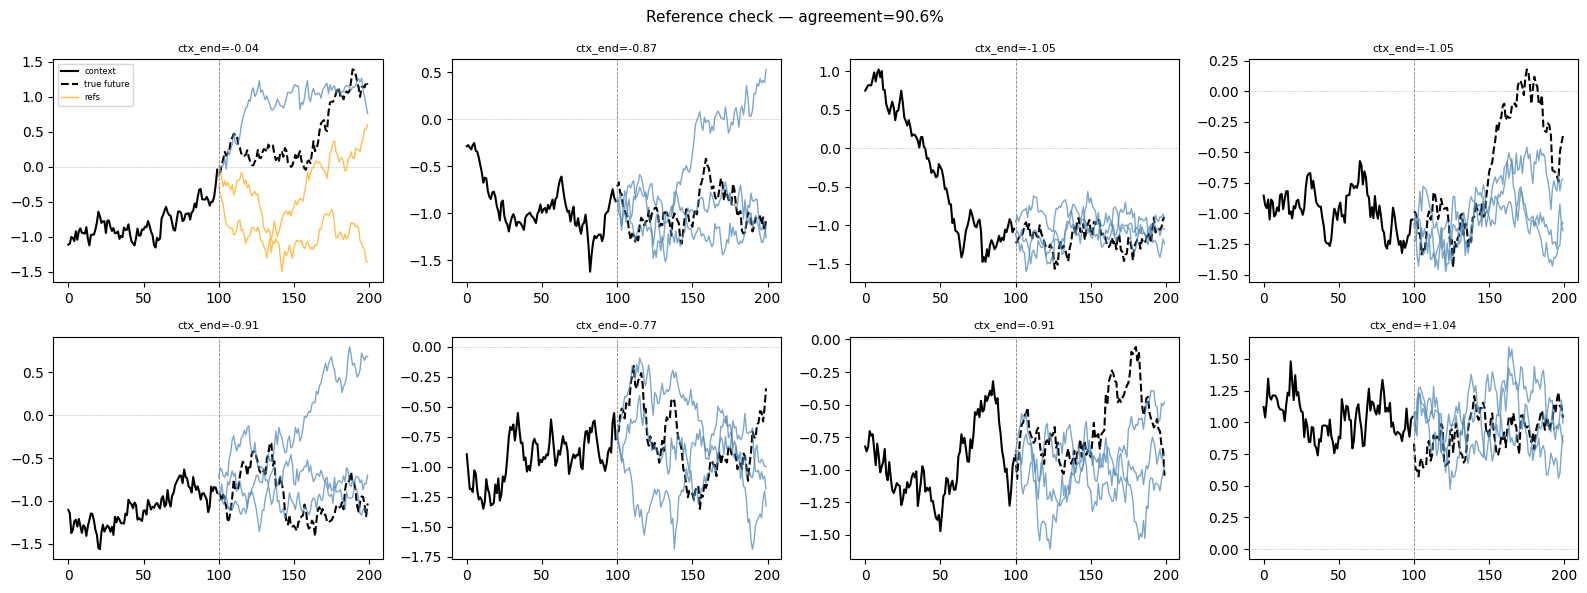

Forecasting:   0%|          | 0/282 [00:06<?, ?it/s]


In [12]:
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Forecasting"):
        batch_cpu = {k: v.cpu().float() for k, v in batch.items()}
        
        observed_data = batch_cpu["observed_data"]
        observed_mask = batch_cpu["observed_mask"]
        observed_tp   = batch_cpu["timepoints"]
        gt_mask       = batch_cpu["gt_mask"]
        reference     = batch_cpu["reference"]

        print(f"observed_data : {observed_data.shape}")
        print(f"observed_mask : {observed_mask.shape}")
        print(f"observed_tp   : {observed_tp.shape}")
        print(f"gt_mask       : {gt_mask.shape}")
        print(f"reference     : {reference.shape}")

        B = observed_data.shape[0]
        k = 3
        H = 100
        L = 100

        ref_reshaped = reference[:, :, 0].reshape(B, k, H)

        ctx_end = observed_data[:, 0, L-1]
        true_fut = observed_data[:, 0, L:]

        print(f"\n=== Reference quality check (batch sample) ===")
        print(f"{'idx':>4}  {'ctx_end':>8}  {'true_fut':>8}  "
              f"{'ref1':>8}  {'ref2':>8}  {'ref3':>8}  "
              f"{'match':>10}")
        print("-" * 70)

        for i in range(20): #(min(16, B)):
            ctx_val = ctx_end[i].item()
            fut_mean = true_fut[i].mean().item()
            r1 = ref_reshaped[i, 0].mean().item()
            r2 = ref_reshaped[i, 1].mean().item()
            r3 = ref_reshaped[i, 2].mean().item()

            fut_sign = int(np.sign(fut_mean))
            r1_match = "✓" if np.sign(r1) == fut_sign else "✗"
            r2_match = "✓" if np.sign(r2) == fut_sign else "✗"
            r3_match = "✓" if np.sign(r3) == fut_sign else "✗"

            print(f"{i:>4}  {ctx_val:>+8.3f}  {fut_mean:>+8.3f}  "
                  f"{r1:>+8.3f}{r1_match}  {r2:>+8.3f}{r2_match}  "
                  f"{r3:>+8.3f}{r3_match}")

        # Correct agreement: references vs true future
        true_signs = np.sign(true_fut.mean(dim=1).numpy())
        ref1_signs = np.sign(ref_reshaped[:, 0].mean(dim=1).numpy())
        agreement = np.mean(true_signs == ref1_signs)
        print(f"\nBatch sign agreement (ref1 vs true future): {agreement:.1%}")

        # Visual check
        fig, axes = plt.subplots(2, 4, figsize=(16, 6))
        t_ctx = np.arange(L)
        t_fut = np.arange(L, L + H)

        for i, ax in enumerate(axes.flat):
            if i >= B:
                ax.axis('off')
                continue

            ctx_np  = observed_data[i, 0, :L].numpy()
            fut_np  = observed_data[i, 0, L:].numpy()
            refs_np = ref_reshaped[i].numpy()

            ax.plot(t_ctx, ctx_np, 'k-', lw=1.5, label='context')
            ax.plot(t_fut, fut_np, 'k--', lw=1.5, label='true future')
            
            for ki in range(k):
                ref_sign = np.sign(refs_np[ki].mean())
                fut_sign = np.sign(fut_np.mean())
                color = 'steelblue' if ref_sign == fut_sign else 'orange'
                ax.plot(t_fut, refs_np[ki], color=color, alpha=0.7, lw=1.0)
            
            ax.axhline(0, color='grey', lw=0.4, ls=':')
            ax.axvline(L, color='grey', lw=0.6, ls='--')
            ax.set_title(f"ctx_end={ctx_np[-1]:+.2f}", fontsize=8)
            if i == 0:
                ax.legend(['context', 'true future', 'refs'], fontsize=6)

        plt.suptitle(f"Reference check — agreement={agreement:.1%}", fontsize=11)
        plt.tight_layout()
        plt.savefig("reference_check.pdf", dpi=150)
        plt.show()

        break